# <span style="color:blue"> Computer Vision — Spring 2026

## Exercise 2

**Deadline:** May 6, 17:00. \
If you need more time, please send a private Piazza message letting me know that you'll submit late. An extension of up to 1 week is automatically approved.

---

In this exercise, you will implement:

1. Straight line detection from image features using Hough Transform.
2. Various feature matching.
3. Computing depth from rectified images.

## Submission guidelines

1. Your submission should include the following files:
   - `hw2_<ID>_<ID>.ipynb` \
     Replace \<ID\> with your ID number(s).
3. Use Jupyter Notebook.
4. Submit this assignment in pairs (no triplets, singles ok).
   * One student should submit the homework, and the other should not submit anything.
   * If you are not the one submitting, make sure that your collaborator indeed submits!
5. **Check that your solution is properly displayed in the last cell!**

## Read the following instructions carefully

1. Write **efficient vectorized** code.
2. You are responsible for the correctness of your code and should add as many tests as you see fit.
3. Use `Python 3` and `NumPy 1.3.2` or above. Before submitting the exercise, restart the kernel and run the notebook from start to finish to make sure everything works.
4. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/) and [NumPy](https://www.numpy.org/devdocs/reference/) only. Any other imports are forbidden unless provided by us.
5. Your code must run without errors. **Code that fails to run will not be graded.**
6. Document your code properly.

## Honor Code
The assignment is a basic tool for learning the material. You can probably find the solution on the web, but then you will not learn anything from it.
You are more than welcome to discuss the assignment with your friends, but you are not allowed to give your code or answers and you are not allowed to use their code or answers.
Feel free to use AI, but you are expected to understand every piece of code that you submit. Please re-read the course's AI policy.
Remember — you take this course in order to learn. Also, the final exam will contain a lot of material from the assignments. 😀

### I declair that I respcet the honor code, and that I understand the course's plagiarism policy and AI policy.
<span style="color:red"> \<Mendel Setti\>

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import null_space

%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots
plt.rcParams['image.cmap'] = 'gray'

import platform
print("Python version: ", platform.python_version())
print("Numpy version: ", np.__version__)

Python version:  3.12.12
Numpy version:  2.3.3


In [3]:
from pathlib import Path

# All images live in the images/ subfolder
example_image_path = Path("images/Sudoku.PNG")
example_img = cv2.imread(str(example_image_path), cv2.IMREAD_GRAYSCALE)

if example_img is None:
    print(f"Could not load image: {example_image_path}")
else:
    print(f"Loaded image: {example_image_path}, shape={example_img.shape}")

# Available images:
#   images/Sudoku.PNG, images/Crosswalk.jpg, images/linesOnTheRoadGray.jpg
#   images/view0.tif, images/view6.tif, images/view1.tif, images/view5.tif

Loaded image: images\Sudoku.PNG, shape=(1053, 1053)


## <span style="color:blue">Section A: Detect Straight Lines </span>

In this part you will use the set of edge points to detect straight lines in an image.\
The input will consist of edge points computed by the Canny edge detector - you can use the implementation of CV2, which is demonstrated below.\
The output will be a set of straight lines in the image. There are two main methods to compute straight lines from such input: the Hough transform and RANSAC. You will implement the Hough transform.

**Hough transform**\
Every 2D line, $\ell$, can be represented by 2 parameters: $r$ and $\theta$ where all points on the line satisfy $r= x\cos\theta + y\sin\theta$.
Let $P_0=(x_0,y_0)$ be the intersection of a normal to $\ell$ from the origin.
The distance between $P_0$ and the origin is given by $r$ and the angle between the normal and the $x$ axis is given by $\theta$.



**Your goal:**     Write the following function\
`straight_lines(image_file, resolution_r, resolution_ang, min_num_points, display, ...)`\
You may add other parameters; make sure to give them default values.
    


To do so, you need to also define the following functions. 
You may add parameters to the functions, as long as you provide clear explanations of their purpose.

In [4]:
# Input: a set of edge points (or corners), and the resolution of the distance and angles.
# Output: the Hough matrix (H) containing votes for lines represented by r and theta.

def H_matrix(L_points, resolution_r, resolution_ang):
    x_max = max(L_points[:,0])
    y_max = max(L_points[:,1])
    max_distance = np.ceil(np.sqrt(x_max**2 + y_max**2))

    r_values = np.arange(-max_distance, max_distance + resolution_r, resolution_r)
    theta_values = np.arange(0, 180, resolution_ang)

    H = np.zeros((len(r_values), len(theta_values)), dtype=int)

    thetas_rad = np.deg2rad(theta_values)
    cos_t = np.cos(thetas_rad)
    sin_t = np.sin(thetas_rad)

    '''for x,y in L_points:
        for idx,theta in enumerate(theta_values):
            theta_rad = np.deg2rad(theta)
            r = x * np.cos(theta_rad) + y * np.sin(theta_rad)
            
            scale = np.around((r - r_values[0]) / resolution_r).astype(int)
            if 0 <= scale < H.shape[0]:
                H[scale, idx] += 1'''
    
    for x, y in L_points:
        r = x * cos_t + y * sin_t

        r_indices = np.round((r - r_values[0]) / resolution_r).astype(int)

        valid = (r_indices >= 0) & (r_indices < H.shape[0])

        theta_indices = np.where(valid)[0]

        H[r_indices[valid], theta_indices] += 1

    return H, r_values, theta_values

# Input: The Hough matrix H, and a threshold for the minimal number of points on the line.
# Output: a list of triplets (r, theta, num_points) where
# num_points is the number of points on that line.

def list_lines(H, r_val, theta_val, min_num_points):
    r_idx, theta_idx = np.where(H >= min_num_points)
    
    triplets = []
    for i in range(len(r_idx)):
        r = r_val[r_idx[i]]
        theta = theta_val[theta_idx[i]]
        votes = H[r_idx[i], theta_idx[i]]
        triplets.append((r, theta, votes))
        
    return triplets


# Display the detected lines in red - overlaid on the original image
def display_lines(im, lines):
    plt.figure(figsize=(8, 8))
    plt.imshow(im, cmap='gray')

    for r, theta, num_points in lines:
        theta_rad = np.deg2rad(theta)

        x0 = r * np.cos(theta_rad)
        y0 = r * np.sin(theta_rad)

        direction_x = -np.sin(theta_rad)
        direction_y = np.cos(theta_rad)

        distance = 1200

        x1 = int(x0 + distance * direction_x)
        x2 = int(x0 -distance * direction_x )

        y1 = int(y0 + distance * direction_y)
        y2 = int(y0 - distance * direction_y)

        point1 = (x1,y1)
        point2 = (x2,y2)
        #plt.plot(point1,point2,'-r',linewidth=2)
        plt.plot([x1, x2], [y1, y2], '-r', linewidth=2)
        
    plt.xlim([0, im.shape[1]])
    plt.ylim([im.shape[0], 0])   # flip y-axis to match image coordinates
    plt.title("Detected Hough Lines")
    plt.show()


In [5]:
# Now use the above functions to implement
def straight_lines(image_file, resolution_r, resolution_ang, min_num_points, display, lower_threshold=100, higher_threshold=200):
    img = cv2.imread(str(image_file),cv2.IMREAD_GRAYSCALE)

    # Edges Detection
    '''lower_threshold = 100
    higher_threshold = 200'''
    edges = cv2.Canny(img,lower_threshold,higher_threshold)

    rows, cols = np.where(edges>0)
    L_points = np.column_stack((cols,rows))

    # Hough Matrix
    hough_matrix, r_values, theta_values  = H_matrix(L_points,resolution_r,resolution_ang)

    # Lines
    lines = list_lines(hough_matrix, r_values, theta_values, min_num_points)

    # Display Lines
    if display:
        display_lines(img,lines)

    return hough_matrix, lines, edges, r_values, theta_values


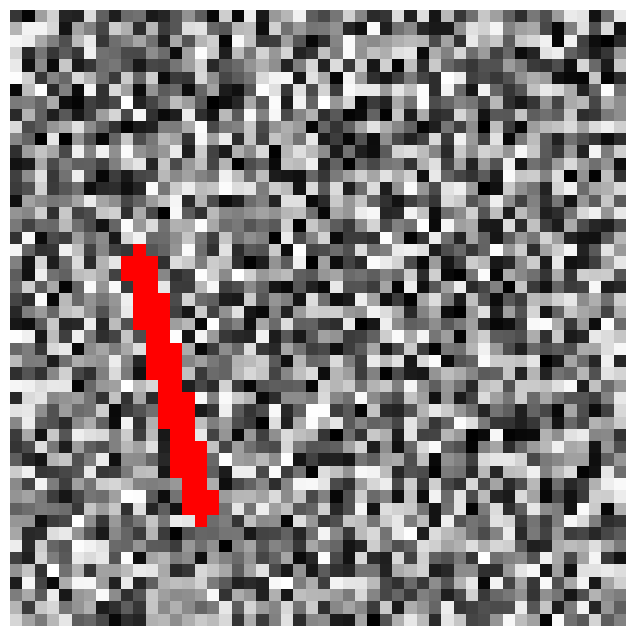

In [6]:
# Here is an example of how to draw a red line
# between (x1, y1) and (x2, y2) on a gray level image, img
# The first step is to create a color image from img.

img = np.random.randint(0, 256, size=(50, 50), dtype=np.uint8)
x1, y1 = 10, 20
x2, y2 = 15, 40
thickness = 2

color_image = np.dstack([img, img, img])
cv2.line(color_image, (x1, y1), (x2, y2), (255, 0, 0), thickness)

plt.imshow(color_image)
plt.axis('off')
plt.show()

(<matplotlib.image.AxesImage at 0x1d595c02c00>, Text(0.5, 1.0, 'Edge Image'))

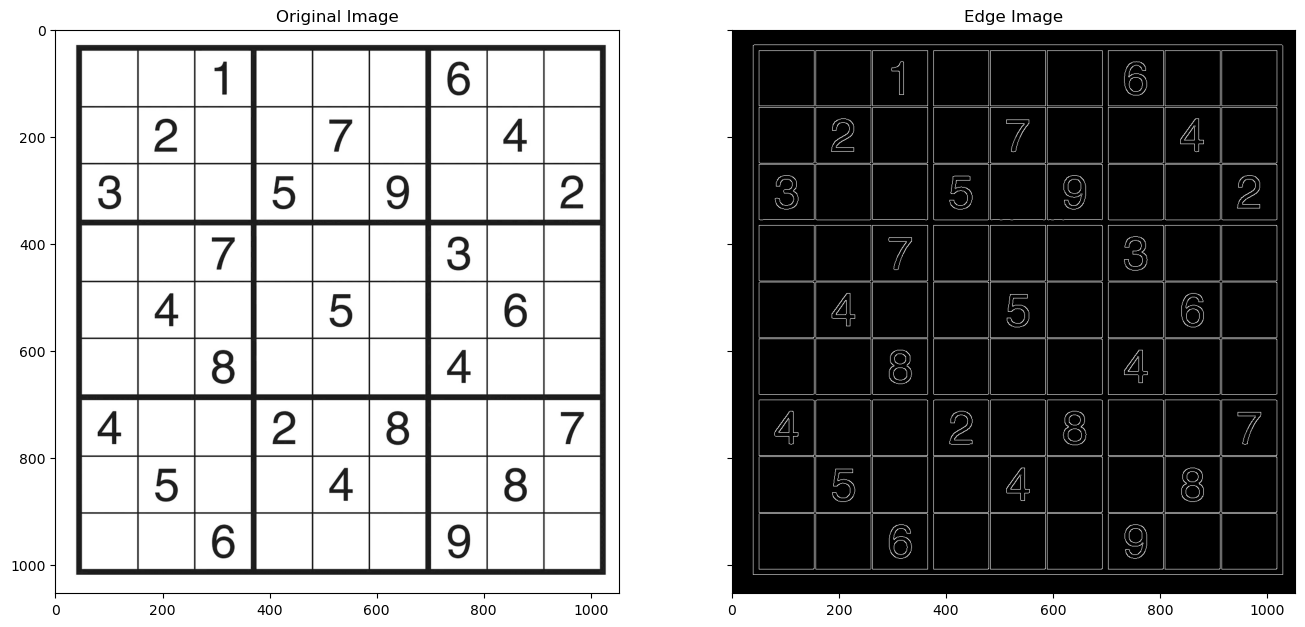

In [7]:
# Here is an example of how to use the CV2 Canny edge detector.
# You can play with the parameters to achieve desired results.

img = cv2.imread(str(Path("images/Sudoku.PNG")), cv2.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

edges = cv2.Canny(img, 250, 500, 5)

plt.rcParams['figure.figsize'] = (16.0, 16.0)
f, (ax1, ax2) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(img), ax1.set_title('Original Image')
ax2.imshow(edges), ax2.set_title('Edge Image')


**Apply and answer**

1. Generate a synthetic image to test your Hough Transform algorithm. \
   Submit the image as well as the results.

2. Apply your algorithm to the following images: Crosswalk, linesOnTheRoadGray, Sudoku. \
   Choose an appropriate set of parameters; you might need different parameters for each image. Don't forget to display the results.
   
3. **Answer**: How the resolutions of $r$ and $\theta$ affect the results? Display images that demonstarte your answer.
   
4. Choose one image and **answer**: how many straight lines did you find with more than 50 points? Display these lines on the image.
   
5. Suggest an algorithm to compute the length of lines in the image. Describe the algorithm without implementing it.
   
6. Suggest three applications that use the results of straight line detection in an image.


### Part 1: Synthetic Image

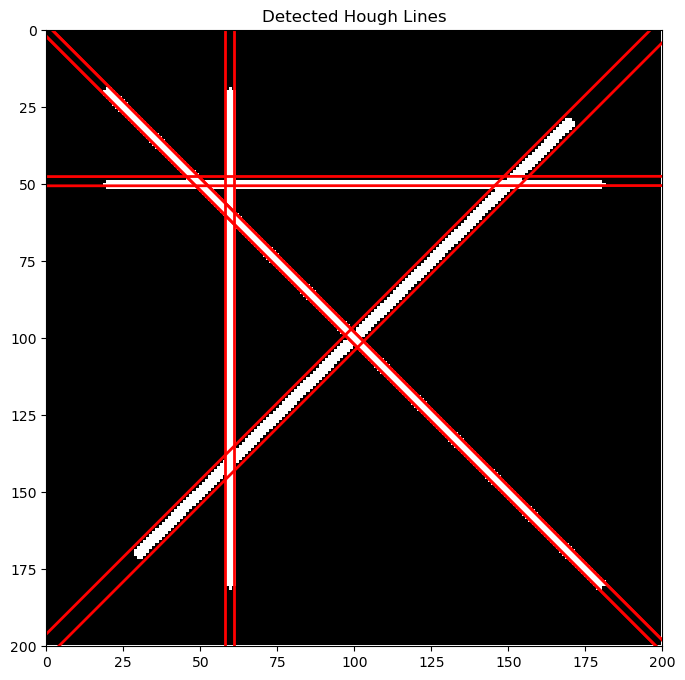


Detected lines:
r = -2.00, theta = 135.00, votes = 152
r = -1.00, theta = 135.00, votes = 152
r = 1.00, theta = 135.00, votes = 152
r = 2.00, theta = 135.00, votes = 152
r = 48.00, theta = 90.00, votes = 145
r = 51.00, theta = 90.00, votes = 146
r = 58.00, theta = 0.00, votes = 145
r = 61.00, theta = 0.00, votes = 146
r = 139.00, theta = 45.00, votes = 136
r = 144.00, theta = 45.00, votes = 138


'plt.figure(figsize=(6, 6))\nplt.imshow(im, cmap="gray")\nplt.title("Synthetic Test Image")\nplt.axis("off")\nplt.show()\n\nprint(expected_lines)'

In [15]:
# Synthetic Image Example

def create_synthetic_line_image(height=200, width=200, thickness=2):
    """
    Create a synthetic grayscale image with known straight lines.

    Output:
    - im: grayscale image
    - expected_lines: description of the lines drawn
    """

    im = np.zeros((height, width), dtype=np.uint8)

    # Draw known lines
    cv2.line(im, (20, 50), (180, 50), 255, thickness)      # horizontal line
    cv2.line(im, (60, 20), (60, 180), 255, thickness)      # vertical line
    cv2.line(im, (30, 170), (170, 30), 255, thickness)     # diagonal line
    cv2.line(im, (20, 20), (180, 180), 255, thickness)     # other diagonal line

    expected_lines = {
        "horizontal": "y = 50",
        "vertical": "x = 60",
        "diagonal_1": "roughly x + y = 200",
        "diagonal_2": "roughly y = x",
    }

    return im, expected_lines


im, expected_lines = create_synthetic_line_image(thickness=2)
cv2.imwrite("synthetic_lines.png", im)

# 3. Run your full Hough pipeline
H, lines, edges, r_values, theta_values = straight_lines(
    image_file="synthetic_lines.png",
    resolution_r=1,
    resolution_ang=1,
    min_num_points=135,
    display=True
)

# 4. Print detected lines
print("\nDetected lines:")
for r, theta, votes in lines:
    print(f"r = {r:.2f}, theta = {theta:.2f}, votes = {votes}")

'''plt.figure(figsize=(6, 6))
plt.imshow(im, cmap="gray")
plt.title("Synthetic Test Image")
plt.axis("off")
plt.show()

print(expected_lines)'''



The synthetic image contains four known straight lines: a horizontal line, a vertical line, and two diagonal lines. The Hough Transform detected lines close to the expected parameters. 

The horizontal line y = 50 was detected around theta = 90° and r ≈ 48–51. 

The vertical line x = 60 was detected around theta = 0° and r ≈ 58–61. The diagonal line y = x was detected around theta = 135° and r ≈ 0. 

The diagonal line x + y = 200 was detected around theta = 45° and r ≈ 139–144, close to the theoretical value 200/sqrt(2) ≈ 141.4.

Several nearby lines were detected for each true line because the synthetic lines have nonzero thickness and the Canny edge detector detects the borders of the thick lines rather than a single center line.

### Part 2: Tests on images

In [19]:
image_files = {
    "Crosswalk": "images/Crosswalk.jpg",
    "linesOnTheRoadGray": "images/linesOnTheRoadGray.jpg",
    "Sudoku": "images/Sudoku.PNG"
}

params = {
    "Crosswalk": {
        "resolution_r": 2,
        "resolution_ang": 1,
        "min_num_points": 450,
        "lower_threshold": 100,
        "higher_threshold": 200
    },
    "linesOnTheRoadGray": {
        "resolution_r": 1,
        "resolution_ang": 1,
        "min_num_points": 160,
        "lower_threshold": 80,
        "higher_threshold": 180
    },
    "Sudoku": {
        "resolution_r": 1,
        "resolution_ang": 1,
        "min_num_points": 150,
        "lower_threshold": 100,
        "higher_threshold": 200
    }
}


Running Hough Transform on Crosswalk


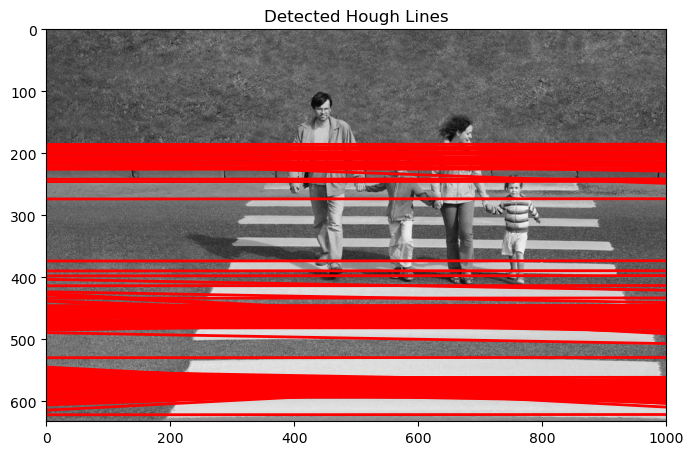

Number of detected lines in Crosswalk: 106

Running Hough Transform on linesOnTheRoadGray


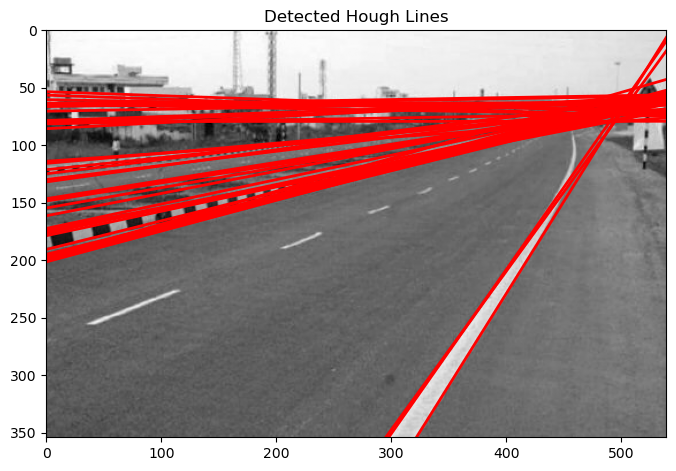

Number of detected lines in linesOnTheRoadGray: 43

Running Hough Transform on Sudoku


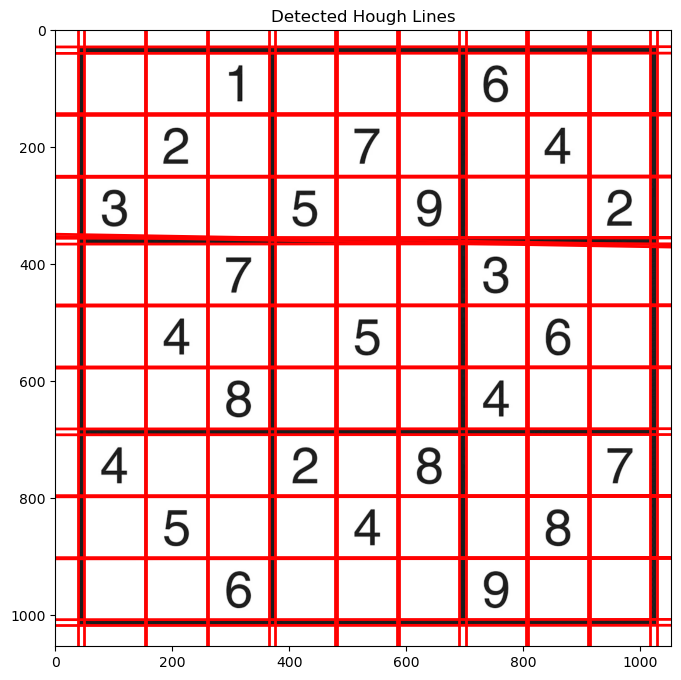

Number of detected lines in Sudoku: 43


In [ ]:
results = {}

for name, path in image_files.items():
    p = params[name]

    print(f"\nRunning Hough Transform on {name}")

    H, lines, edges, r_values, theta_values = straight_lines(
        image_file=path,
        resolution_r=p["resolution_r"],
        resolution_ang=p["resolution_ang"],
        min_num_points=p["min_num_points"],
        display=True,
        lower_threshold=p["lower_threshold"],
        higher_threshold=p["higher_threshold"]
    )

    if name == 'Sudoku':
        lines_on_sudoku_overlay = lines # Check this part before submitting in case they want the whole image and not just the lines

    results[name] = {
        "H": H,
        "lines": lines,
        "edges": edges,
        "r_values": r_values,
        "theta_values": theta_values
    }

    print(f"Number of detected lines in {name}: {len(lines)}")

### Part 3: Effects of r and theta


Sudoku with resolution_r=1, resolution_ang=1


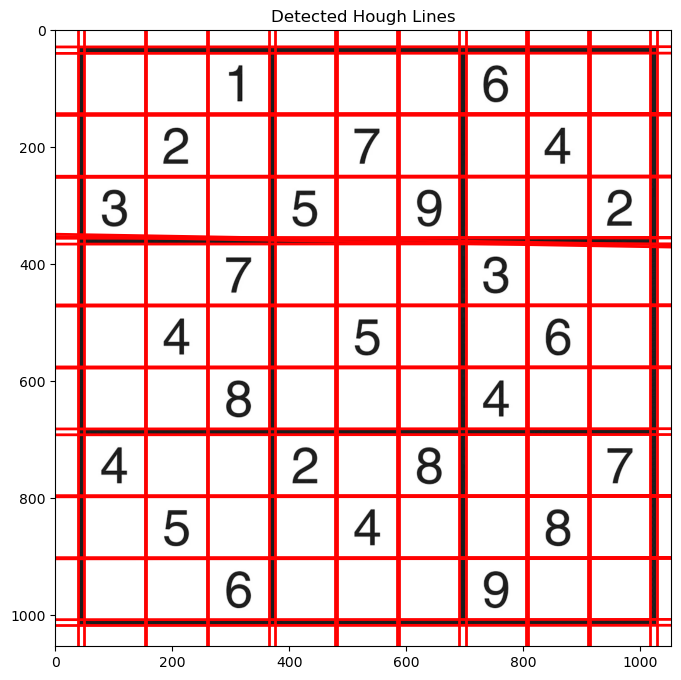

Number of detected lines: 43

Sudoku with resolution_r=2, resolution_ang=1


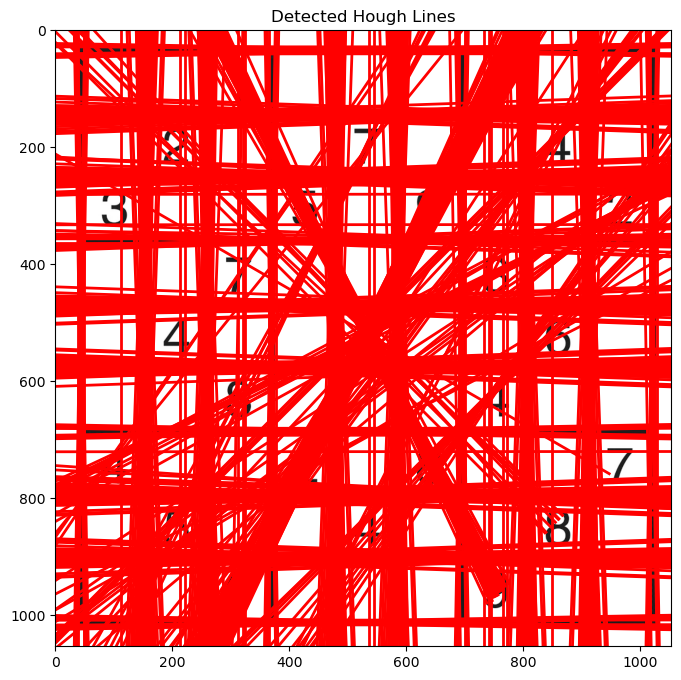

Number of detected lines: 612

Sudoku with resolution_r=5, resolution_ang=1


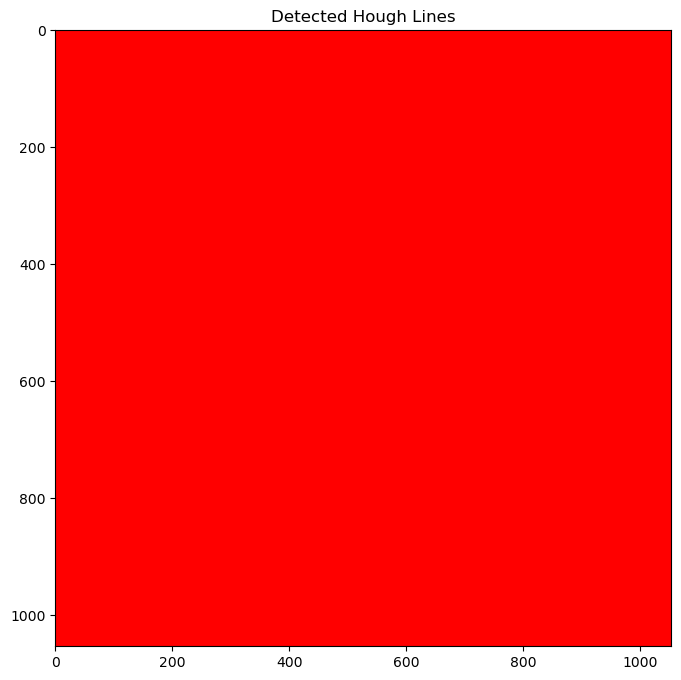

Number of detected lines: 29536

Sudoku with resolution_r=1, resolution_ang=2


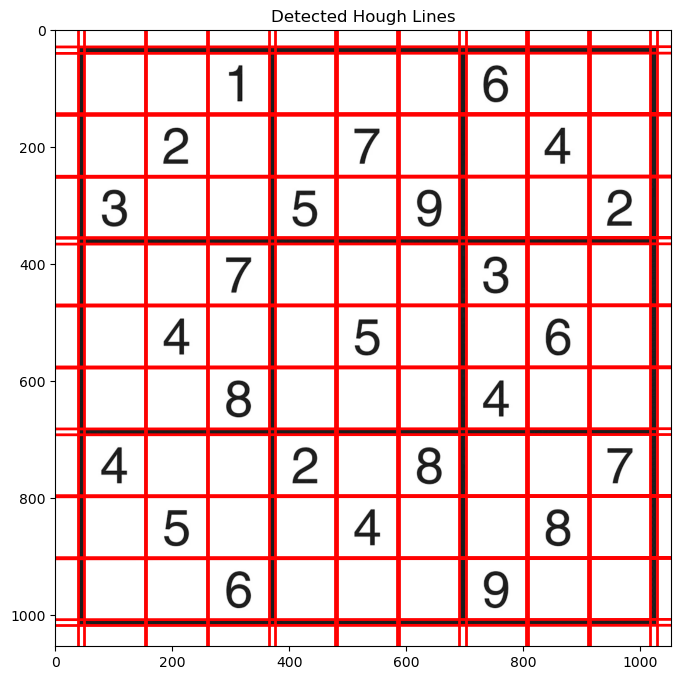

Number of detected lines: 41

Sudoku with resolution_r=1, resolution_ang=5


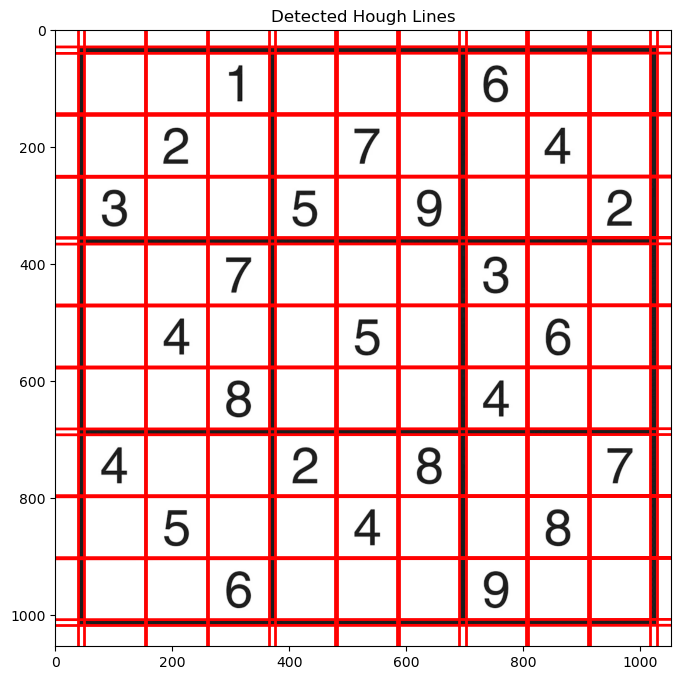

Number of detected lines: 41

Sudoku with resolution_r=5, resolution_ang=5


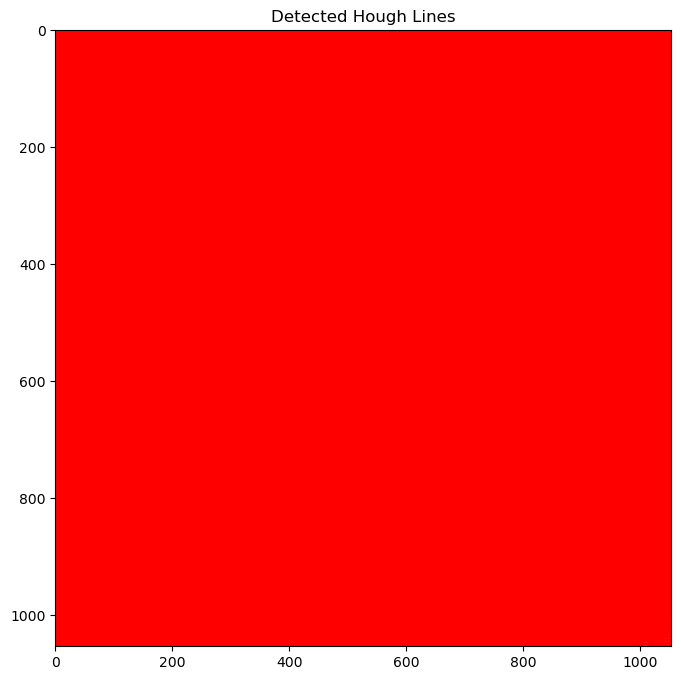

Number of detected lines: 5813


In [ ]:
# ------------------------------------------------------------
# 3. Effect of r and theta resolutions
# Demonstration on one image, for example Sudoku
# ------------------------------------------------------------

sudoku_path = image_files["Sudoku"]

resolution_experiments = [
    (1, 1),
    (2, 1),
    (5, 1),
    (1, 2),
    (1, 5),
    (5, 5)
]

for res_r, res_theta in resolution_experiments:
    print(f"\nSudoku with resolution_r={res_r}, resolution_ang={res_theta}")

    H_tmp, lines_tmp, edges_tmp, r_tmp, theta_tmp = straight_lines(
        image_file=sudoku_path,
        resolution_r=res_r,
        resolution_ang=res_theta,
        min_num_points=150,
        display=True,
        lower_threshold=100,
        higher_threshold=200
    )

    print(f"Number of detected lines: {len(lines_tmp)}")


resolution_effect = """
The experiments were done using the same minimum of points detected to be considered a line, here 150. The only parameters changing from test to test are r and theta. 
The resolutions of r and theta affect the size of the bins in the Hough accumulator.

When r is small, for example r=1, the accumulator is more precise and the real lines matches the sudoku lines. 
When the value of r increase (2 or 5), each resolution bin represent a wider range of distances. As a result, more edge pixel get voted into the same bins causing many accumulator to pass the threshold which output a more cluttered of even totally red image.
In our case, for the same theta, r=1 output 43 lines while r=2 finds 612 lines and r = 5 finds 29536 lines.

In this case, the influence of theta was limited since the sudoku is mostly composed of horizontal and vertical lines (theta = 0 or 90). 
These angles are still represented by theta = 2 and theta = 5 whcih gives us a similar result in bose case, i.e. 41 lines detected.

In general, smaller resolution give more accurate lines but may produce duplicate nearby detection while larger resoltions are less precise and can merge vote from differents nearby lines. 
"""

### Part 4: Straight lines with more than 50 points

I used the synthetic image for this part. Using resolution_r = 1, resolution_theta = 1°, and min_num_points = 50, the algorithm found 105 accumulator cells with more than 50 votes.

The number is larger than the four actual lines in the image because each real line produces several nearby detections in the Hough accumulator. 
This happens because the drawn lines have thickness, Canny detects line borders, and neighboring r/theta bins may also receive many votes.

For visualization, I displayed the strongest detected lines which are the same line that were detected above in part 1. These correspond to the expected horizontal, vertical, and diagonal lines in the synthetic image.

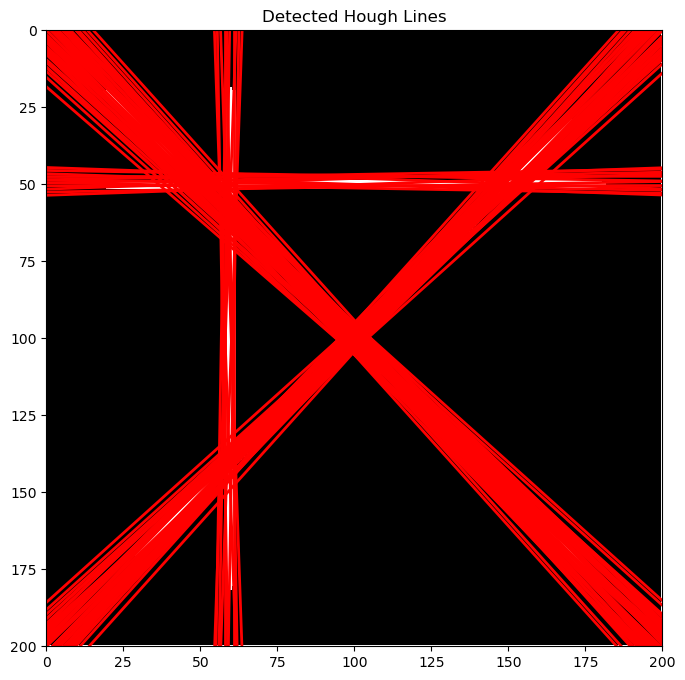


Number of straight lines found in Synthetic with more than 50 points:
105
r = -59.00, theta = 179.00, votes = 53
r = -57.00, theta = 178.00, votes = 51
r = -56.00, theta = 179.00, votes = 63
r = -55.00, theta = 178.00, votes = 60
r = -11.00, theta = 138.00, votes = 56
r = -10.00, theta = 138.00, votes = 55
r = -9.00, theta = 138.00, votes = 56
r = -8.00, theta = 138.00, votes = 57
r = -7.00, theta = 137.00, votes = 68
r = -7.00, theta = 138.00, votes = 61
r = -6.00, theta = 136.00, votes = 63
r = -6.00, theta = 137.00, votes = 85
r = -5.00, theta = 136.00, votes = 86
r = -5.00, theta = 137.00, votes = 77
r = -5.00, theta = 138.00, votes = 52
r = -4.00, theta = 136.00, votes = 80
r = -4.00, theta = 137.00, votes = 70
r = -4.00, theta = 138.00, votes = 53
r = -3.00, theta = 136.00, votes = 87
r = -3.00, theta = 137.00, votes = 65
r = -2.00, theta = 135.00, votes = 152
r = -2.00, theta = 136.00, votes = 98
r = -1.00, theta = 134.00, votes = 56
r = -1.00, theta = 135.00, votes = 152
r = -

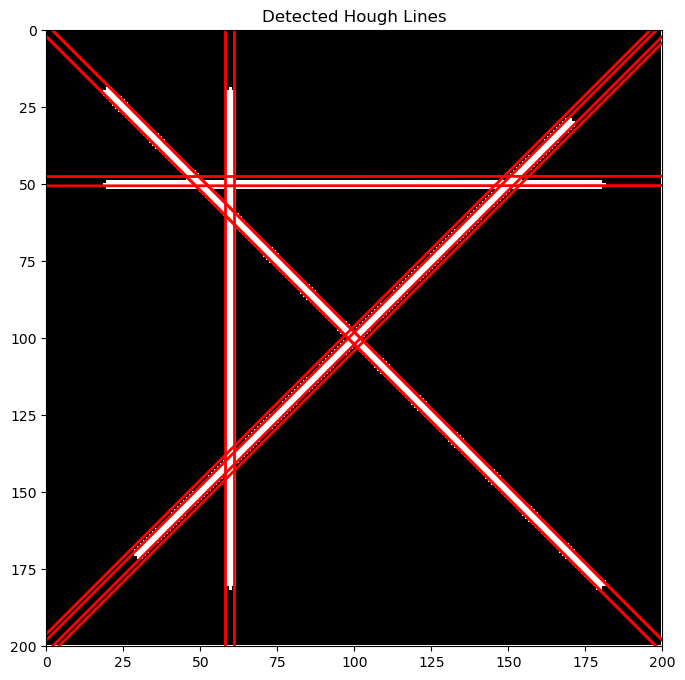


Strongest displayed lines:
r = -2.00, theta = 135.00, votes = 152
r = -1.00, theta = 135.00, votes = 152
r = 1.00, theta = 135.00, votes = 152
r = 2.00, theta = 135.00, votes = 152
r = 51.00, theta = 90.00, votes = 146
r = 61.00, theta = 0.00, votes = 146
r = 48.00, theta = 90.00, votes = 145
r = 58.00, theta = 0.00, votes = 145
r = 144.00, theta = 45.00, votes = 138
r = 139.00, theta = 45.00, votes = 136
r = 140.00, theta = 45.00, votes = 130
r = 143.00, theta = 45.00, votes = 130


In [ ]:
chosen_image = "Synthetic" 
chosen_path = 'synthetic_lines.png'

H_chosen, lines_chosen, edges_chosen, r_chosen, theta_chosen = straight_lines(
    image_file=chosen_path,
    resolution_r=1,
    resolution_ang=1,
    min_num_points=50,
    display=True,
    lower_threshold=100,
    higher_threshold=200
)

lines_more_than_50 = lines_chosen

print(f"\nNumber of straight lines found in {chosen_image} with more than 50 points:")
print(len(lines_more_than_50))

for r, theta, votes in lines_more_than_50:
    print(f"r = {r:.2f}, theta = {theta:.2f}, votes = {votes}")


strongest_lines = sorted(lines_more_than_50, key=lambda x: x[2], reverse=True)[:12]

img = cv2.imread(chosen_path, cv2.IMREAD_GRAYSCALE)
display_lines(img, strongest_lines)

print("\nStrongest displayed lines:")
for r, theta, votes in strongest_lines:
    print(f"r = {r:.2f}, theta = {theta:.2f}, votes = {votes}")


### Part 5 - 6: Algorithm and Applications of straight line detection

In [ ]:
line_length_algorithm = """
To compute the length of a detected line, we first take its parameters r and theta, which represent the line itself.
We then scan all the edge pixels (white pixels) in the image and select the ones which satisfy the equaton : 
| x*cos(theta) + y*sin(theta) -r | < epsilon 
where epsilon is a small tolerance (threshold).

Next, we sort the pixels along the line direction. Line vector = (-sin(theta), cos(theta)). We can also sort by the dominant axis, x or y, for horizontal and vertical lines.

After that, we iterate throught the sorted pixels and group them into continuous segments. A new segment is created when the distance between 2 consecutives pixels is larger than a threshold that we select.

Then, we compute the Euclidean distance between the first and last pixel for each separate segments. This gives us the estimated length of each lines segments. 
"""


line_detection_applications = [
    "Lane detection in autonomous driving or driver-assistance systems to assist with steering.",
    "Document analysis, for example detecting table borders or page alignment.",
    "Detecting structured objects in images, such as buildings, roads, crosswalks, Sudoku grids, or industrial parts."
]


In [ ]:
# Section A - Apply and answer (student code)
# TODO: student implementation

# lines_on_sudoku_overlay = ...  # colour image with detected lines on Sudoku
# resolution_effect = "..."
# line_length_algorithm = "..."
# line_detection_applications = ["...", "...", "..."]

## <span style="color:blue">Section B: Patch Matching </span>
**In this part you will match interest points across two images.**

There are two functions between vectors $v$ and $u$ that you will consider:\
a. Distance: Sum of Square Distance (SSD). That is,  $SSD(u,v)=(u-v)\cdot(u-v)$.\
b. Similarity: Normalized Cross Correlation (NCC). That is,  $NCC(u,v)={u\cdot v \over ||u||||v||}$.

The patch descriptor:
1. A vector with the pixels' grey level.
2. A histogram (30 bins) of the pixels' grey level.
3. A vector with the pixels' gradient strength.
4. A histogram (30 bins) of the pixels' gradient strength.

In [ ]:
# Implement the following functions:

# Input: two vectors
# Output: distance (scalar) between two patches
def SSD(patch_descr_1, patch_descr_2):

    patch_descr_1 = np.asarray(patch_descr_1).flatten()
    patch_descr_2 = np.asarray(patch_descr_2).flatten()

    if patch_descr_1.shape != patch_descr_2.shape:
        raise ValueError("Vectors of different length!")
    
    ssd = np.sum(np.square(patch_descr_1-patch_descr_2))
    return ssd

# Input: two vectors
# Output: normalized cross correlation (scalar) between two patches
def NCC(patch_descr_1, patch_descr_2):

    patch_descr_1 = np.asarray(patch_descr_1).flatten()
    patch_descr_2 = np.asarray(patch_descr_2).flatten()

    if patch_descr_1.shape != patch_descr_2.shape:
        raise ValueError("Vectors of different length!")
    
    numerator = patch_descr_1 @ patch_descr_2
    denominator = np.linalg.norm(patch_descr_1) * np.linalg.norm(patch_descr_2)
    if denominator == 0:
        return 0.0
    
    result = numerator / denominator
    return result

# For the following, im is an image, p is a pixel location, size is the patch size.
# Output: a descriptor vector
# You can use the histogram function of open cv or numpy

def patch_from_im(im, p, size):
    half_window = size // 2
    x = int(round(p[0]))
    y = int(round(p[1]))
    h, w = im.shape[:2]

    if (y - half_window < 0 or y + half_window >= h or 
        x - half_window < 0 or x + half_window >= w):
        return None

    patch = im[
        y - half_window:y + half_window + 1,
        x - half_window:x + half_window + 1
    ].astype(np.float32)

    patch = patch.flatten()
    # return patch

    # Zero-mean normalization
    patch = patch - np.mean(patch)

    norm = np.linalg.norm(patch)

    if norm < 1e-8:
        return None

    patch = patch / norm

    return patch

def normalize_patch(patch):
    # Zero-mean + unit norm. Returns None if patch is flat (no texture).
    patch = patch - np.mean(patch)
    norm = np.linalg.norm(patch)

    if norm < 1e-8:
        return None

    patch = patch / norm
    return patch

def hist_patch_im(im, p, size, bins=30):
    pixels = patch_from_im(im,p,size)

    if pixels is None:
        return None
    
    hist,_ = np.histogram(pixels,bins=bins,range=(0,256))

    # Normalize histogram so descriptors are comparable
    if np.sum(hist) > 0:
        hist = hist / np.sum(hist)
    
    return hist

def gradient(im, p, size):
    # I am assuming that we can use the Sobel operator to compute the gradient of the patch
    patch_flat = patch_from_im(im, p, size)

    if patch_flat is None:
        return None
    
    # Compute gradients in x and y directions
    patch = patch_flat.reshape((size,size)).astype(np.float32)
    sobel_x = cv2.Sobel(patch, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(patch, cv2.CV_64F, 0, 1, ksize=3)

    gradient_strenght = np.sqrt(sobel_x ** 2 + sobel_y ** 2).flatten()
    #return gradient_strenght  # Currently that's the version that works need to check the one below later to see if normalization is needed
    norm = np.linalg.norm(gradient_strenght)
    if norm < 1e-8:
        return None  # completely flat patch, no edges
    return gradient_strenght / norm

def hist_gradient(im, p, size, bins=30):
    gradient_strenght = gradient(im,p,size)
    hist,_ = np.histogram(gradient_strenght,bins=bins,range=(0,1)) # range was changed from (0,256) to (0,1) because the gradient is normalized to unit norm

    # Normalization
    if np.sum(hist) > 0:
        hist = hist / np.sum(hist)

    return hist

In [3]:
# Vectorized version of SSD and NCC

def vectorized_SSD(M1, M2):
    # Using the formula: (a-b)^2 = a^2 + b^2 - 2ab
    # M1 is (N1, D), M2 is (N2, D)

    M1 = np.asarray(M1).astype(np.float32)
    M2 = np.asarray(M2).astype(np.float32)

    if M1.shape[1] != M2.shape[1]:
        raise ValueError("Descriptors must have the same dimension.")
    
    sq1 = np.sum(M1**2, axis=1, keepdims=True) # Shape: (N1, 1)
    sq2 = np.sum(M2**2, axis=1)                # Shape: (N2,)
    dot_product = M1 @ M2.T                    # Shape: (N1, N2)
    
    # Broadcasting takes care of the rest
    ssd_matrix = sq1 + sq2 - 2 * dot_product
    # Clip to 0 to prevent negative distances due to floating point inaccuracies
    return np.maximum(ssd_matrix, 0)

def vectorized_NCC(M1, M2):
    # Using the formula: (u . v) / (||u|| * ||v||)

    M1 = np.asarray(M1).astype(np.float32)
    M2 = np.asarray(M2).astype(np.float32)

    if M1.shape[1] != M2.shape[1]:
        raise ValueError("Descriptors must have the same dimension.")
    
    dot_product = M1 @ M2.T
    
    norm1 = np.linalg.norm(M1, axis=1, keepdims=True) + 1e-8 # Add epsilon to avoid div by zero
    norm2 = np.linalg.norm(M2, axis=1) + 1e-8
    
    ncc_matrix = dot_product / (norm1 * norm2)
    return ncc_matrix

<!-- **Apply and answer** -->
   
1. Compute the corners in a pair of images (e.g., `images/view0.tif` and `images/view6.tif`).
2. Experiment with 3 ways to perform the matching:
   1. Choose up to 2000 of the strongest corners (you can use fewer) and find a matching between the corners in the pair of images.
      - Choose a fixed scale and use it to define a patch around each corner.
      - To display the matching, use the function `cv2.hconcat([im1, im2])`, which concatenates two images horizontally, and then draw lines as described in the previous section.
   2. Use up to 4000 of the strongest corners (you can use fewer) in each image and use the matching only between corners that have approximately the same y-coordinate (up to a threshold). The `images` folder contains pairs of rectified images.
   3. Use the ratio between the best and second best matches to find good matches.
      - You can use NCC or SSD on the desriptor of your choice.
      - You can either apply or not apply the $y$-coordinate constraint (B).
      - **Present** examples that demonstrate the effectiveness of using the ratio.
3. Study the differences between the various descriptors and also the use of SSD or NCC. 
   - **Present**  examples that demonstrate your findings.
4. Identify incorrect pairs of matched points.
   **Mark and display** for cases (A), (B), and (C) a pair of incorrectly matched points.
   **Answer:**
   - In which of the 3 cases are there more incorrect matches?
   - What may be the reason for the incorrect matches?
5. In which regions of the scene were most of the reliable matches found?


In [ ]:
# Helper functions for Section B

def compute_descriptor(im, p, size, descriptor_type="gray"):
    """
    descriptor_type options:
    - "gray"       : raw gray-level patch vector
    - "gray_hist"  : histogram of gray levels
    - "grad"       : raw gradient strength vector
    - "grad_hist"  : histogram of gradient strengths
    """
    if descriptor_type == "gray":
        return patch_from_im(im, p, size)

    elif descriptor_type == "gray_hist":
        return hist_patch_im(im, p, size)

    elif descriptor_type == "grad":
        return gradient(im, p, size)

    elif descriptor_type == "grad_hist":
        return hist_gradient(im, p, size)

    else:
        raise ValueError("Unknown descriptor type")

def build_descriptor_matrix(im, corners, size, descriptor_type="gray"):
    valid_corners = []
    descriptors = []

    for p in corners:
        desc = compute_descriptor(im, p, size, descriptor_type)

        if desc is not None:
            valid_corners.append(p)
            descriptors.append(desc)

    return np.array(valid_corners), np.array(descriptors, dtype=np.float32)

def match_points(corners1, corners2, score_matrix, metric="NCC", y_constraint=False, y_threshold=3, ratio_test=False, ratio_threshold=0.95, 
                 mutual_check=True, disparity_constraint=False, min_disp=-200, max_disp=200):
    """
    corners are OpenCV format: (x, y)

    metric:
    - NCC: higher is better
    - SSD: lower is better
    """

    matched_pts1 = []
    matched_pts2 = []
    match_scores = []

    eps = 1e-8

    # Best match from image 2 back to image 1, for mutual check
    if mutual_check:
        if metric == "NCC":
            best_2_to_1 = np.argmax(score_matrix, axis=0)
        else:
            best_2_to_1 = np.argmin(score_matrix, axis=0)

    for i in range(score_matrix.shape[0]):

        scores = score_matrix[i].copy()

        valid_mask = np.ones(len(corners2), dtype=bool)

        # -----------------------------------------
        # Y-coordinate constraint
        # -----------------------------------------
        if y_constraint:
            y1 = corners1[i][1]
            y2 = corners2[:, 1]
            valid_mask &= np.abs(y2 - y1) <= y_threshold

        # -----------------------------------------
        # Optional disparity / x constraint
        # -----------------------------------------
        if disparity_constraint:
            x1 = corners1[i][0]
            x2 = corners2[:, 0]

            disparity = x1 - x2

            valid_mask &= (disparity >= min_disp) & (disparity <= max_disp)

        valid_indices = np.where(valid_mask)[0]

        if len(valid_indices) < 1:
            continue

        valid_scores = scores[valid_indices]

        # -----------------------------------------
        # Sort candidates
        # -----------------------------------------
        if metric == "NCC":
            order = np.argsort(valid_scores)[::-1]
        elif metric == "SSD":
            order = np.argsort(valid_scores)
        else:
            raise ValueError("metric must be 'NCC' or 'SSD'.")

        best_local = order[0]
        best_idx = valid_indices[best_local]
        best_score = scores[best_idx]

        # -----------------------------------------
        # Ratio test
        # -----------------------------------------
        if ratio_test:
            if len(order) < 2:
                continue

            second_local = order[1]
            second_idx = valid_indices[second_local]

            second_score = scores[second_idx]

            if metric == "NCC":
                ratio = second_score / (best_score + eps)

                # For NCC, ratio close to 1 means ambiguous.
                if ratio >= ratio_threshold:
                    continue

            else:
                ratio = best_score / (second_score + eps)

                # For SSD, ratio close to 1 means ambiguous.
                if ratio >= ratio_threshold:
                    continue

        # -----------------------------------------
        # Mutual check
        # -----------------------------------------
        if mutual_check:
            if best_2_to_1[best_idx] != i:
                continue

        matched_pts1.append(corners1[i])
        matched_pts2.append(corners2[best_idx])
        match_scores.append(best_score)

    return (
        np.array(matched_pts1),
        np.array(matched_pts2),
        np.array(match_scores)
    )


def draw_matches(im1, im2, pts1, pts2, scores=None, metric="NCC", max_matches=80):
    out_img = cv2.hconcat([im1, im2])
    out_img = cv2.cvtColor(out_img, cv2.COLOR_GRAY2BGR)

    w = im1.shape[1]

    if scores is not None and len(scores) > 0:
        if metric == "NCC":
            order = np.argsort(scores)[::-1]
        else:
            order = np.argsort(scores)

        order = order[:max_matches]
        pts1 = pts1[order]
        pts2 = pts2[order]
    else:
        pts1 = pts1[:max_matches]
        pts2 = pts2[:max_matches]

    for p1, p2 in zip(pts1, pts2):
        ptA = (int(p1[0]), int(p1[1]))
        ptB = (int(p2[0]) + w, int(p2[1]))

        cv2.line(out_img, ptA, ptB, (0, 255, 0), 1)
        cv2.circle(out_img, ptA, 3, (0, 0, 255), -1)
        cv2.circle(out_img, ptB, 3, (0, 0, 255), -1)

    return out_img



Case A matches: 241
Case B matches: 218
Case C matches: 203


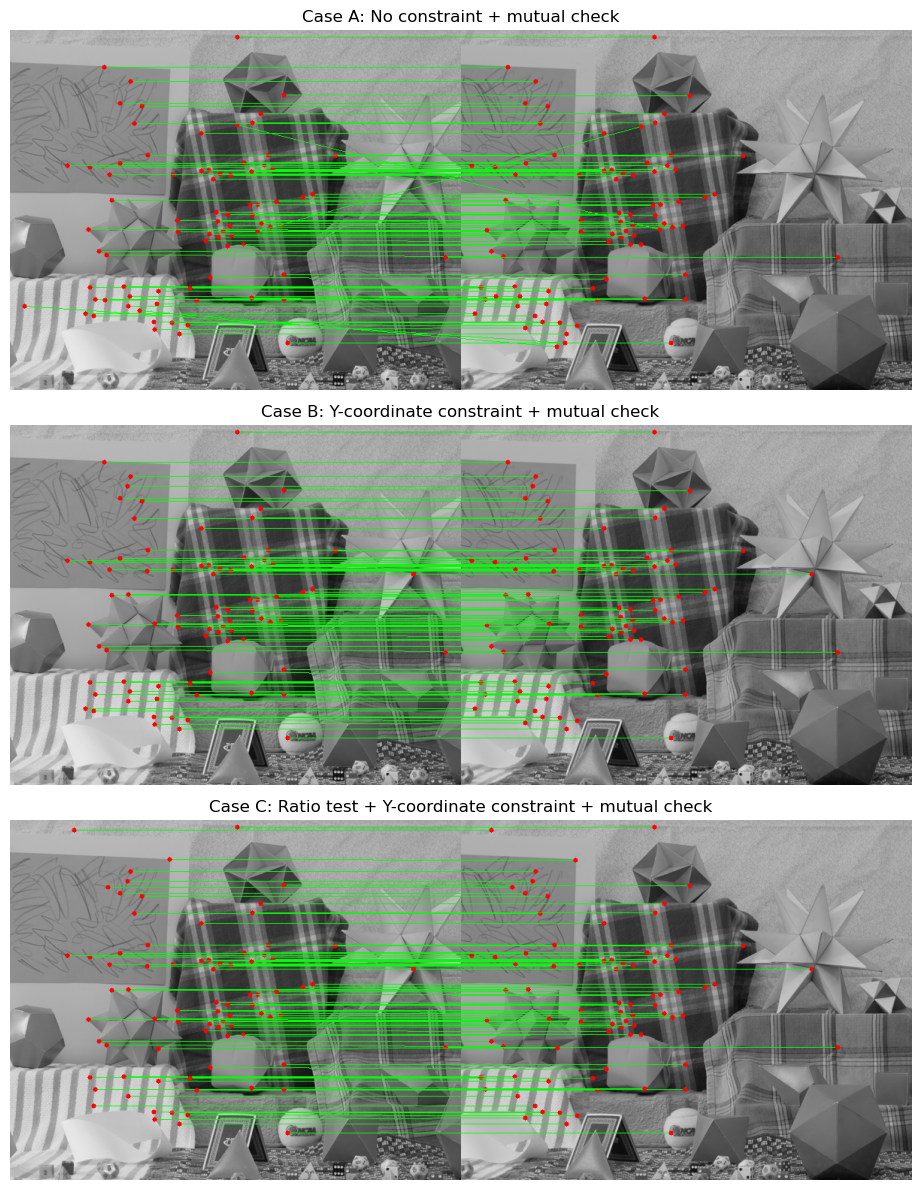

In [7]:
# ==========================================
# Load images
# ==========================================

im1 = cv2.imread("images/view0.tif", cv2.IMREAD_GRAYSCALE)
im2 = cv2.imread("images/view6.tif", cv2.IMREAD_GRAYSCALE)

patch_size = 15
descriptor_type = "gray"
metric = "NCC"

# ==========================================
# Detect corners
# ==========================================

corners1 = cv2.goodFeaturesToTrack(
    im1,
    maxCorners=4000,
    qualityLevel=0.01,
    minDistance=10
)

corners2 = cv2.goodFeaturesToTrack(
    im2,
    maxCorners=4000,
    qualityLevel=0.01,
    minDistance=10
)

corners1 = corners1.reshape(-1, 2)
corners2 = corners2.reshape(-1, 2)

# ==========================================
# Build descriptors
# ==========================================

valid_corners1, M1 = build_descriptor_matrix(
    im1,
    corners1,
    patch_size,
    descriptor_type=descriptor_type
)

valid_corners2, M2 = build_descriptor_matrix(
    im2,
    corners2,
    patch_size,
    descriptor_type=descriptor_type
)

score_matrix = vectorized_NCC(M1, M2)

# ==========================================
# Cases and visualization
# ==========================================

# Case A: no constraint, but with mutual check
pts1_A, pts2_A, scores_A = match_points(
    valid_corners1[:2000],
    valid_corners2,
    score_matrix[:2000],
    metric="NCC",
    y_constraint=False,
    ratio_test=False,
    mutual_check=True
)

# Case B: y constraint + mutual check
pts1_B, pts2_B, scores_B = match_points(
    valid_corners1,
    valid_corners2,
    score_matrix,
    metric="NCC",
    y_constraint=True,
    y_threshold=3,
    ratio_test=False,
    mutual_check=True
)

# Case C: y constraint + ratio test + mutual check
pts1_C, pts2_C, scores_C = match_points(
    valid_corners1,
    valid_corners2,
    score_matrix,
    metric="NCC",
    y_constraint=True,
    y_threshold=3,
    ratio_test=True,
    ratio_threshold=0.95,
    mutual_check=True
)

print("Case A matches:", len(pts1_A))
print("Case B matches:", len(pts1_B))
print("Case C matches:", len(pts1_C))

match_overlay_A = draw_matches(im1, im2, pts1_A, pts2_A, scores_A, metric="NCC", max_matches=80)
match_overlay_B = draw_matches(im1, im2, pts1_B, pts2_B, scores_B, metric="NCC", max_matches=80)
match_overlay_C = draw_matches(im1, im2, pts1_C, pts2_C, scores_C, metric="NCC", max_matches=80)

plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.imshow(cv2.cvtColor(match_overlay_A, cv2.COLOR_BGR2RGB))
plt.title("Case A: No constraint + mutual check")
plt.axis("off")

plt.subplot(3, 1, 2)
plt.imshow(cv2.cvtColor(match_overlay_B, cv2.COLOR_BGR2RGB))
plt.title("Case B: Y-coordinate constraint + mutual check")
plt.axis("off")

plt.subplot(3, 1, 3)
plt.imshow(cv2.cvtColor(match_overlay_C, cv2.COLOR_BGR2RGB))
plt.title("Case C: Ratio test + Y-coordinate constraint + mutual check")
plt.axis("off")

plt.tight_layout()
plt.show()

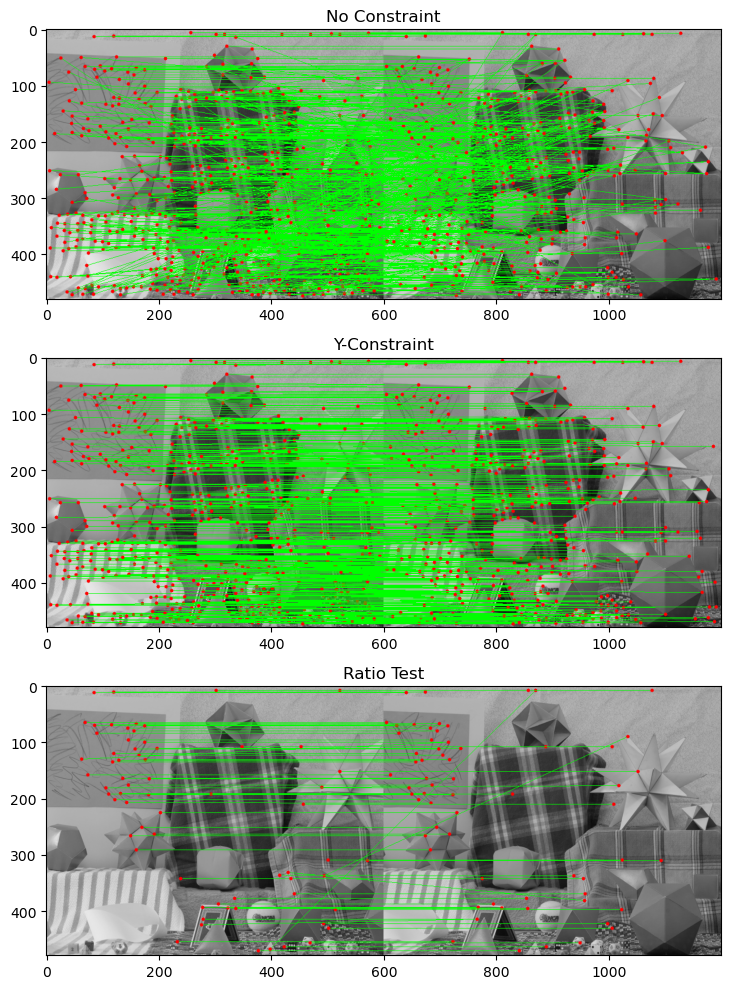


3. Differences between descriptors & SSD/NCC: 
- Using simple pixel patches with SSD is highly sensitive to lighting changes between views. NCC is normalized, making it much more robust to global illumination changes. 
- Histograms remove spatial layout information (two completely different looking patches might have the same histogram), leading to more false matches.
- Gradients emphasize edges and structure rather than absolute intensity, making them excellent when lighting shifts drastically.

4. Incorrect pairs:
- Case (A) [No constraint] contains the most incorrect matches by far. Points match with completely unrelated areas in the background because we only search for visual similarity globally.
- The reason for incorrect matches is mostly repetitive textures (like bricks, windows, or foliage), where many patches look identical. Without geometric constraints or ratio tests, the algorithm guesses blindly among similar patches.

5. Reliable matches regions:
- The most reliable mat

In [5]:
# ==========================================
# Section B - Apply and answer (student code)
# ==========================================

# 1. Load images
im1 = cv2.imread('images/view0.tif', cv2.IMREAD_GRAYSCALE)
im2 = cv2.imread('images/view6.tif', cv2.IMREAD_GRAYSCALE)
patch_size = 11 # Odd number

# 1. Compute corners using Shi-Tomasi (Good Features to Track)
corners1 = cv2.goodFeaturesToTrack(im1, maxCorners=4000, qualityLevel=0.01, minDistance=10)
corners2 = cv2.goodFeaturesToTrack(im2, maxCorners=4000, qualityLevel=0.01, minDistance=10)

corners1 = corners1.reshape(-1, 2) # Reshape to (N, 2) arrays of (x, y)
corners2 = corners2.reshape(-1, 2)

# Helper function to extract descriptors and build matrix M
def build_descriptor_matrix(im, corners, size):
    valid_corners = []
    descriptors = []
    for p in corners:
        desc = patch_from_im(im, p, size) # Change to hist_patch_im or gradient if you wish to experiment
        if desc is not None:
            descriptors.append(desc)
            valid_corners.append(p)
    return np.array(valid_corners), np.array(descriptors)

# Build M1 and M2
valid_corners1, M1 = build_descriptor_matrix(im1, corners1, patch_size)
valid_corners2, M2 = build_descriptor_matrix(im2, corners2, patch_size)

# Calculate the Distance/Similarity Matrices
# We will use NCC for this example (higher is better)
similarity_matrix = vectorized_NCC(M1, M2)

# Helper function to draw matches
def draw_matches(im1, im2, pts1, pts2):
    out_img = cv2.hconcat([im1, im2])
    out_img = cv2.cvtColor(out_img, cv2.COLOR_GRAY2BGR)
    w = im1.shape[1]
    for p1, p2 in zip(pts1, pts2):
        ptA = (int(p1[0]), int(p1[1]))
        ptB = (int(p2[0]) + w, int(p2[1]))
        cv2.line(out_img, ptA, ptB, (0, 255, 0), 1)
        cv2.circle(out_img, ptA, 3, (0, 0, 255), -1)
        cv2.circle(out_img, ptB, 3, (0, 0, 255), -1)
    return out_img

# ---------------------------------------------------------
# 2.1 Basic Matching (All-to-all without constraints)
# ---------------------------------------------------------
# Limit to top 2000 for this part
top_2000 = min(2000, similarity_matrix.shape[0])
sim_matrix_2k = similarity_matrix[:top_2000, :]
corners_2k = valid_corners1[:top_2000]

best_matches_idx = np.argmax(sim_matrix_2k, axis=1) # Find highest NCC per row
matched_pts1 = corners_2k
matched_pts2 = valid_corners2[best_matches_idx]

match_overlay = draw_matches(im1, im2, matched_pts1, matched_pts2)

# ---------------------------------------------------------
# 2.2 Matching with Y-coordinate constraint
# ---------------------------------------------------------
y_threshold = 5 # Maximum vertical pixel difference between rectified images

constrained_pts1 = []
constrained_pts2 = []

for i in range(similarity_matrix.shape[0]):
    y1 = valid_corners1[i][1]
    
    # Mask out matches that violate the y-constraint by giving them a terrible score (-inf)
    valid_y_mask = np.abs(valid_corners2[:, 1] - y1) <= y_threshold
    
    if np.any(valid_y_mask):
        scores = similarity_matrix[i].copy()
        scores[~valid_y_mask] = -np.inf # Exclude points with large Y difference
        best_idx = np.argmax(scores)
        
        constrained_pts1.append(valid_corners1[i])
        constrained_pts2.append(valid_corners2[best_idx])

match_overlay_y = draw_matches(im1, im2, constrained_pts1, constrained_pts2)

# ---------------------------------------------------------
# 2.3 Lowe's Ratio Test (Ratio between Best and Second Best)
# ---------------------------------------------------------
ratio_threshold = 0.8 # Typical threshold for Lowe's ratio test
good_pts1 = []
good_pts2 = []

for i in range(similarity_matrix.shape[0]):
    scores = similarity_matrix[i]
    
    # Sort scores descending (for NCC, highest is best)
    # If using SSD, sort ascending and use sorted_indices[0] / sorted_indices[1] < ratio
    sorted_indices = np.argsort(scores)[::-1] 
    best_idx = sorted_indices[0]
    second_best_idx = sorted_indices[1]
    
    best_score = scores[best_idx]
    second_best_score = scores[second_best_idx]
    
    # Ratio test (for NCC: second_best / best < ratio)
    if (second_best_score / best_score) < ratio_threshold:
        good_pts1.append(valid_corners1[i])
        good_pts2.append(valid_corners2[best_idx])

match_overlay_ratio = draw_matches(im1, im2, good_pts1, good_pts2)

# Display Results
plt.figure(figsize=(15, 10))
plt.subplot(311), plt.imshow(cv2.cvtColor(match_overlay, cv2.COLOR_BGR2RGB)), plt.title("No Constraint")
plt.subplot(312), plt.imshow(cv2.cvtColor(match_overlay_y, cv2.COLOR_BGR2RGB)), plt.title("Y-Constraint")
plt.subplot(313), plt.imshow(cv2.cvtColor(match_overlay_ratio, cv2.COLOR_BGR2RGB)), plt.title("Ratio Test")
plt.tight_layout()
plt.show()

# ==========================================
# Answers to textual questions
# ==========================================
matching_analysis = """
3. Differences between descriptors & SSD/NCC: 
- Using simple pixel patches with SSD is highly sensitive to lighting changes between views. NCC is normalized, making it much more robust to global illumination changes. 
- Histograms remove spatial layout information (two completely different looking patches might have the same histogram), leading to more false matches.
- Gradients emphasize edges and structure rather than absolute intensity, making them excellent when lighting shifts drastically.

4. Incorrect pairs:
- Case (A) [No constraint] contains the most incorrect matches by far. Points match with completely unrelated areas in the background because we only search for visual similarity globally.
- The reason for incorrect matches is mostly repetitive textures (like bricks, windows, or foliage), where many patches look identical. Without geometric constraints or ratio tests, the algorithm guesses blindly among similar patches.

5. Reliable matches regions:
- The most reliable matches were found in regions with high contrast and unique geometric structures (e.g., sharp architectural corners, distinct window frames, or non-repetitive textures). Flat regions (like sky or blank walls) yield no corners, and highly repetitive regions (leaves/bricks) fail the ratio test.
"""
print(matching_analysis)

In [ ]:
# Section B - Apply and answer (student code)
# TODO: student implementation

# match_overlay = ...    # color image showing matches (no y-constraint)
# match_overlay_y = ...  # color image showing matches (with y-constraint)
# matching_analysis = "..."
# reliable_match_regions = "..."

**Implementation details**

You can compute the NCC or SSD patch by patch. This will probably take longer than using matrix multiplications via NumPy.

Using matrices:
1. Generate a 1D vector from each descriptor.
2. Generate a matrix $M_1$:  rows  are  the descriptors of img1.
3. Generate a matrix $M_2$:  columns  are  the descriptors of img2.
4. Use `M = np.matmul(M_1,M_2)` or the shorthand `M = M_1 @ M_2` to multiple the matrices.
   * what is the value in $M(i,j)$?
5. Think of how to normalize `M` for NCC calculation, and how to use `M` for SSD calculation. \
Hint: consider the formula for $(a-b)^2$.
    
You can change the functions `SSD()` and `NCC()` above to use your vectorized implementation (i.e., their inputs should be matrices instead of vectors, where each column is one descriptor).

## <span style="color:blue">Section C: Extracting 3D Structure</span>

In this part you will compute the 3D structure from a pair of rectified images.


**Input:**
1. A pair of two rectified images, $im1$ and $im2$ (e.g., `images/view1.tif` and `images/view5.tif`).
2. A window size $(s_x,s_y$).
3. Disparity range $(d_{min},d_{max})$ (see below).

**Output:**
1. A matrix, $D$ with the disparity map for the left image.
2. Three matrices X, Y, Z with the x, y, z-coordinates of each pixel in the left image. Assign zero for pixels for which the disparity was not computed.

Note: all matrices $im1, im2, D, X, Y, Z$ have the same dimensions.

**Instructions:**
1. Your code should assume a pair of rectified images as input. You can use `images/view1.tif` and `images/view5.tif`.
2. Write a function that receives two rectified images, and computes dense matching along lines with the same $y$-coordinate.
    * You can use any of the descriptors from Part B. The patch size should be given as a parameter.
    * Use NCC for the similarity measure.
    * You can assume that you are given the range of disparities, $d_{min},d_{max}$ as an input. \
      For example, if  $(d_{min},d_{max})=(20,120)$ it follows that the corresponding point of  $(x,y)$ in the left image, is in the range $(x-120:x-20,y)$ in the right image.
    * Consider matching with and without order preserving. 
    * List all parameters you use for your function.
    * Hints on efficient implementation are given below.
3. Write a function that computes the disparity based on (2).  
    * **Display** the disparity $D$ map as an image
4. Compute the depth map using the disparity.
    * Assume that scaled focal lengths are $α_x=α_y=1$.
    * The distance between the cameras is 160mm.
    * Add to your disparity depth map the value 100, since images were cropped. 
    * Display the disparity as an image. 
5. Compute the matrices X,Y,Z
    * Present the object given by X,Y,Z using a 3D plot.


**Implementation**\
You can implement the computation of the similarity and the disparity directly by an exhaustive search. You can also use the idea from Part B. A more efficeint and elegant way is described below. You are welcome to try, but you do not have to.


General idea for the **vectorized solution** (you will need to fill in the gaps):
* Let $w$ and $h$ be the width and the height of the image respectively.
* First assume that the patch size is $1\times s_y$.
* Given two $1\times w$ rows, $r_1$ and $r_2$ which are corresponding rows of the two images. Compute the $w\times w$ matrix $R12=r_1^T r_2$. The values $R12(i,j)$ consists of the product of two pixels $r_1(i)\cdot r_2(j)$.
* Find a matrix that, when convolved with $R12$, will produce the correlation of the $s_y$ 1D neighborhood of $r_1(i)$ and $r_2(j)$.
* Think about how to normalize this correlation using the same ideas as in the previous section.
* Extend your solution to work for a general patch size $s_x\times s_y$. Hint: $R$ and the convolution kernels are no longer 2D matrices.
* Up to here, we considered each row seperately, hence we need to loop over all rows of the images. There is a way to do it without looping, but not in this assignemnt :)


In [ ]:
# Section C implementation area (student code)
# TODO: student implementation
def compute_disparity_map(im1, im2, window_size, d_min, d_max):
    """
    Compute a dense disparity map for the left image using patch matching.

    Parameters
    ----------
    im1 : np.ndarray
        Left rectified grayscale image.

    im2 : np.ndarray
        Right rectified grayscale image.

    window_size : tuple
        Patch size as (s_x, s_y).

    d_min : int
        Minimum disparity.

    d_max : int
        Maximum disparity.

    Returns
    -------
    D : np.ndarray
        Disparity map with the same shape as im1.
        Pixels where disparity is not computed should remain zero.
    """

    h, w = im1.shape
    
    s_x, s_y = window_size
    half_size_x, half_size_y = s_x // 2, s_y // 2

    D = np.zeros_like(im1, dtype=np.float32)

    for y in range(half_size_y, h -half_size_y):
        for x in range(half_size_x, w - half_size_x):
           
            patch1 = im1[
                y - half_size_y : y + half_size_y + 1,
                x - half_size_x : x + half_size_x + 1
            ]

            best_ncc = -np.inf
            best_disparity = 0

            # Searching for the best disparity
            for d in range(d_min, d_max + 1):
                
                x_right = x - d

                # Checking if the right image patch is centered or not
                if x_right - half_size_x < 0:
                    continue
                
                if x_right + half_size_x >= w:
                    continue
                
                patch2 = im2[
                    y - half_size_y : y + half_size_y + 1,
                    x_right - half_size_x : x_right + half_size_x + 1
                ]
                # NCC between the left patch and the right patch
                patch1_vec = patch1.flatten()
                patch2_vec = patch2.flatten()
                ncc = NCC(patch1_vec,patch2_vec)

                # Keep the best NCC and Disparity
                if ncc > best_ncc:
                    best_ncc = ncc
                    best_disparity = d

            D[y,x] = best_disparity

    return D


def compute_3d_structure(D, B=160, offset=100):
    """
    Compute the 3D coordinates X, Y, Z from the disparity map.

    Parameters
    ----------
    D : np.ndarray
        Disparity map.

    B : float
        Baseline between the two cameras in millimeters.

    offset : float
        Disparity offset caused by cropping.

    Returns
    -------
    X, Y, Z : np.ndarray
        Matrices containing the 3D coordinates.
        Pixels where disparity was not computed should remain zero.
    """

    # TODO: Get the height and width of D.
    h, w = D.shape
    alphas = 1
    # TODO: Initialize X, Y, Z as zero matrices with the same shape as D.
    X = np.zeros_like(D,dtype=np.float32)
    Y = np.zeros_like(D,dtype=np.float32)
    Z = np.zeros_like(D,dtype=np.float32)


    # TODO: Create coordinate grids for image coordinates x and y.
    x_coordinates, y_coordinates = np.meshgrid(np.arange(w),np.arange(h))

    # TODO: Create a mask for valid pixels where D > 0.
    mask = D > 0
    # TODO: Compute the corrected disparity:
    #       corrected_disparity = D + offset
    corrected_disparity = D + offset
    # TODO: Compute depth Z for valid pixels.
    #       Use the stereo depth formula with alpha_x = alpha_y = 1.
    Z[mask] = B / corrected_disparity[mask]
    # TODO: Compute X coordinates for valid pixels using the pinhole camera model.
    # TODO: Compute Y coordinates for valid pixels using the pinhole camera model.
    X[mask] = x_coordinates[mask] * Z[mask]
    Y[mask] = y_coordinates * Z[mask]

    # TODO: Return X, Y, Z.

    return X,Y,Z


def display_disparity_map(D):
    """
    Display the disparity map as an image.
    """

    # TODO: Create a figure.

    # TODO: Display D using an appropriate colormap.

    # TODO: Add a colorbar.

    # TODO: Add title and axis labels if needed.

    # TODO: Show the plot.

    pass


def plot_3d_point_cloud(X, Y, Z):
    """
    Display the 3D reconstruction as a point cloud.
    """

    # TODO: Create a 3D figure and axis.

    # TODO: Select only valid points where Z > 0.

    # TODO: Extract valid X, Y, Z values.

    # TODO: Plot the points using a 3D scatter plot.

    # TODO: Optionally invert the Y axis for nicer visualization.

    # TODO: Add axis labels and title.

    # TODO: Show the plot.

    pass


if __name__ == "__main__":

    # TODO: Load the left image as grayscale.

    # TODO: Load the right image as grayscale.

    # TODO: Convert both images to float, for example np.float32.

    # TODO: Choose the patch/window size.

    # TODO: Choose the disparity range d_min and d_max.

    # TODO: Call compute_disparity_map.

    # TODO: Display the disparity map.

    # TODO: Call compute_3d_structure.

    # TODO: Display the 3D point cloud.

    pass
###############################################################################
# IMPORTANT – Final variables for the Results Display cell.
# Define ALL of these somewhere in your notebook before running the last cell.
#
# Section A:
#   lines_on_sudoku_overlay  – colour image (H x W x 3) of Sudoku with detected lines drawn in red
#   resolution_effect        – string: how r and theta resolution affect results
#   line_length_algorithm    – string: algorithm to compute line length
#   line_detection_applications – list of 3 strings
#
# Section B:
#   match_overlay            – colour image (H x (W1+W2) x 3) showing matches between view0 & view6
#   match_overlay_y          – same as above but with y-coordinate constraint
#   matching_analysis        – string: analysis of incorrect matches
#   reliable_match_regions   – string: where reliable matches are found
#
# Section C:
#   disparity_map            – 2D array (H x W) disparity values
#   depth_map                – 2D array (H x W) depth values
###############################################################################

## Simple Submission Flow

1. Implement your code in Section A, Section B, and Section C cells.
2. Define the final variables listed below.
3. Run `Results Display` (last cell).
4. Submit this notebook (results are displayed at the end).

## Final Variables to Display

Define these variables in your notebook code. The last cell reads them directly.

**Section A – Hough Transform:**
- `lines_on_sudoku_overlay` – colour image (H x W x 3) of Sudoku with detected lines drawn in red
- `resolution_effect` (short text - answer to Q3)
- `line_length_algorithm` (short text - answer to Q5)
- `line_detection_applications` (list of 3 strings - answer to Q6)

**Section B – Patch Matching:**
- `match_overlay` – colour image showing matches between view0 & view6 (no y-constraint)
- `match_overlay_y` – colour image showing matches with y-coordinate constraint
- `matching_analysis` (short text - answer to Q4)
- `reliable_match_regions` (short text - answer to Q5)

**Section C – Stereo Depth:**
- `disparity_map` (2D array)
- `depth_map` (2D array)

## Final Results Display

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def _show_text(name, value):
    if value is None:
        print(f"  {name}: MISSING")
    else:
        print(f"  {name}: {value}")


def _show_image(name, value, figsize=(6, 5)):
    if value is None:
        print(f"  {name}: MISSING")
        return
    arr = np.asarray(value)
    print(f"  {name}: shape={arr.shape}, dtype={arr.dtype}")
    plt.figure(figsize=figsize)
    if arr.ndim == 2:
        plt.imshow(arr, cmap="gray")
    else:
        plt.imshow(arr)
    plt.title(name)
    plt.axis("off")
    plt.show()


# ==================== Section A ====================
print("=" * 60)
print("Section A - Hough Transform")
print("=" * 60)
_show_image("lines_on_sudoku_overlay",
            globals().get("lines_on_sudoku_overlay", None))
_show_text("resolution_effect",
           globals().get("resolution_effect", None))
_show_text("line_length_algorithm",
           globals().get("line_length_algorithm", None))
_show_text("line_detection_applications",
           globals().get("line_detection_applications", None))

# ==================== Section B ====================
print("\n" + "=" * 60)
print("Section B - Patch Matching")
print("=" * 60)
_show_image("match_overlay",
            globals().get("match_overlay", None), figsize=(14, 5))
_show_image("match_overlay_y",
            globals().get("match_overlay_y", None), figsize=(14, 5))
_show_text("matching_analysis",
           globals().get("matching_analysis", None))
_show_text("reliable_match_regions",
           globals().get("reliable_match_regions", None))

# ==================== Section C ====================
print("\n" + "=" * 60)
print("Section C - Depth from Stereo")
print("=" * 60)
disp = globals().get("disparity_map", None)
depth = globals().get("depth_map", None)
if disp is not None:
    arr = np.asarray(disp)
    print(f"  disparity_map: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={arr.min():.1f}, max={arr.max():.1f}")
    plt.figure(figsize=(8, 5))
    plt.imshow(arr, cmap="jet"); plt.colorbar(label="disparity")
    plt.title("disparity_map"); plt.axis("off"); plt.show()
else:
    print("  disparity_map: MISSING")
if depth is not None:
    arr = np.asarray(depth)
    print(f"  depth_map: shape={arr.shape}, dtype={arr.dtype}, "
          f"min={arr.min():.1f}, max={arr.max():.1f}")
    plt.figure(figsize=(8, 5))
    plt.imshow(arr, cmap="jet"); plt.colorbar(label="depth (mm)")
    plt.title("depth_map"); plt.axis("off"); plt.show()
else:
    print("  depth_map: MISSING")